In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [29]:
df = pd.read_csv('CO2 Emissions_Canada.csv')
df.drop(['Make', 'Model', 'Vehicle Class', 'Transmission'], axis=1, errors='ignore', inplace=True)

In [30]:
# One-hot encode the 'Fuel Type' column
df_encoded = pd.get_dummies(df, columns=['Fuel Type'], prefix='', prefix_sep='', drop_first=True)
# Convert all columns to integer type
df_encoded = df_encoded.astype(int)

In [31]:
X = df_encoded[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)',
                 'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)',
                 'Fuel Consumption Comb (mpg)', 'E', 'N', 'X', 'Z']]
y = df_encoded['CO2 Emissions(g/km)']
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [32]:
# Create and train the Decision Tree Regressor
regressor = DecisionTreeRegressor(max_depth=4, random_state=42)
regressor.fit(X_train, Y_train)
Y_pred = regressor.predict(X_test)

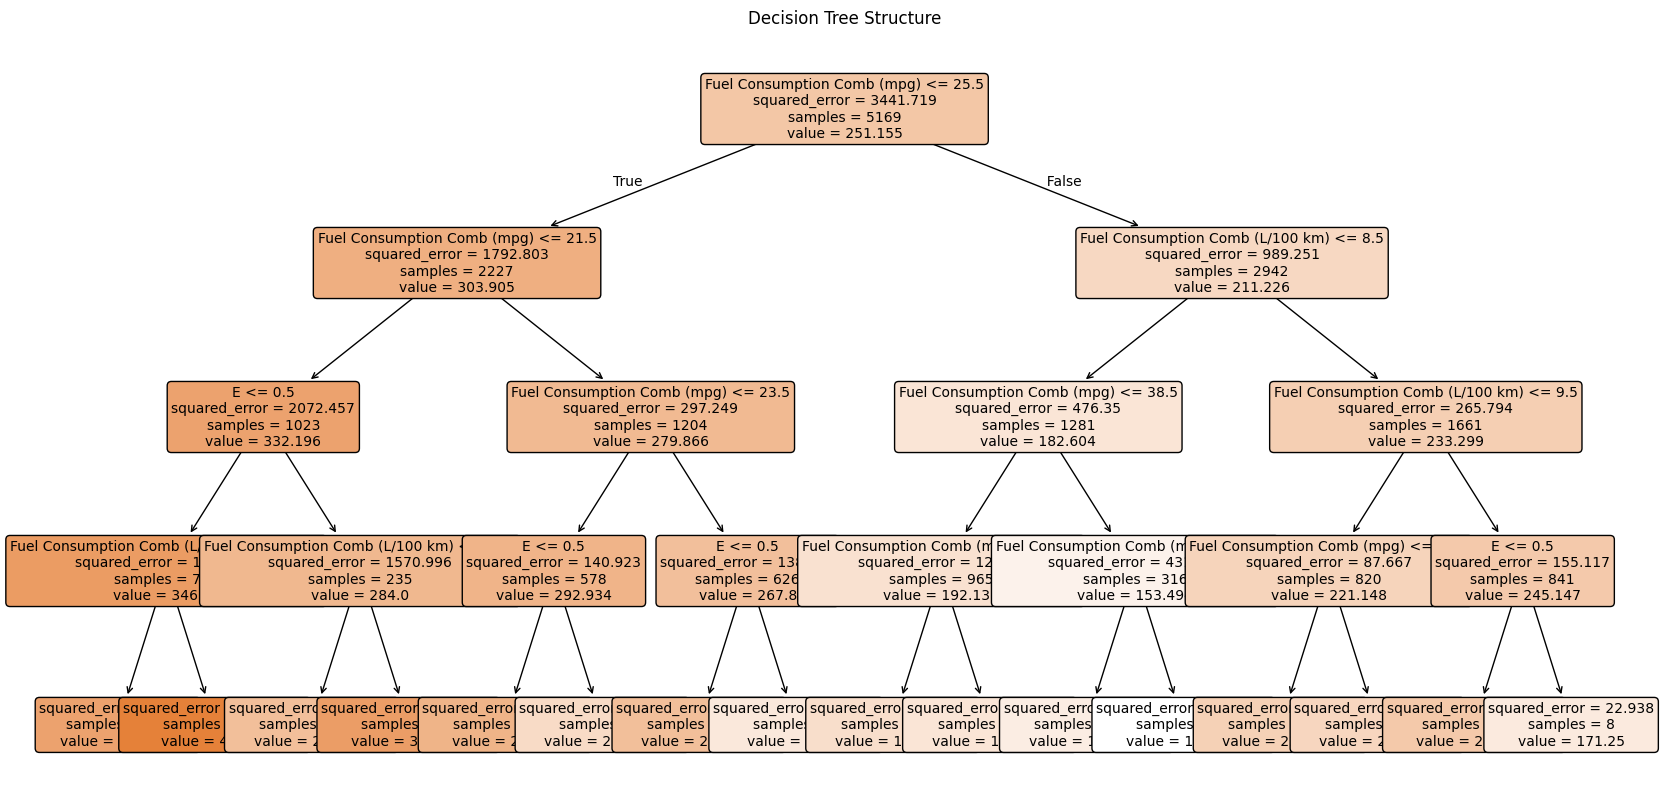

In [33]:
# Visualizing decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    regressor,
    feature_names=X.columns,  # Use the actual feature names from X
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure")
plt.show()

In [34]:
Y_pred_train = regressor.predict(X_train)

In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_train = mean_absolute_error(Y_train, Y_pred_train)
mse_train = mean_squared_error(Y_train, Y_pred_train)
r2_train = r2_score(Y_train, Y_pred_train)
# Print the results
print("Training Metrics:")
print(f'Mean Absolute Error: {mae_train}')
print(f'Mean Squared Error: {mse_train}')
print(f'R-squared: {r2_train}')

Training Metrics:
Mean Absolute Error: 8.528781485475845
Mean Squared Error: 157.51100302916745
R-squared: 0.9542347837946357


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae_test = mean_absolute_error(Y_test, Y_pred)
mse_test = mean_squared_error(Y_test, Y_pred)
r2_test = r2_score(Y_test, Y_pred)
# Print the results
print("Testing Metrics:")
print(f'Mean Absolute Error: {mae_test}')
print(f'Mean Squared Error: {mse_test}')
print(f'R-squared: {r2_test}')

Testing Metrics:
Mean Absolute Error: 8.719200290249155
Mean Squared Error: 160.54267378716662
R-squared: 0.9524699024221095
